In [1]:
%pip install python-dotenv
%pip install roboflow
%pip install supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 152.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 21.1 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
userdata.get('TEST')

'test'

In [3]:
# from dotenv import load_dotenv

# load_dotenv()

from roboflow import Roboflow

# if google colab run:
from google.colab import userdata
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("caretech-qnw0y").project("v1-caretech-combined-dataset")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to [V1]-CareTech-Combined-Dataset-1 in yolov8:: 100%|██████████| 58572/58572 [00:06<00:00, 9169.82it/s] 


In [4]:
!mv "/content/[V1]-CareTech-Combined-Dataset-1" "/content/V1-CareTech-Combined-Dataset-1"
!rm -rf "/content/[V1]-CareTech-Combined-Dataset-1"

In [5]:
%pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.7 MB/s eta 0:00:00


In [6]:
# script to split training dataset
import os
import shutil
from pathlib import Path
import supervision as sv


# creates a new folder with just the images and labels
dir = Path('/content/V1-CareTech-Combined-Dataset-1')
unified_dir = Path('/content/all')
split_path = Path('/content/split')

new_img_dir = unified_dir / 'images'
new_label_dir = unified_dir / 'labels'

new_img_dir.mkdir(parents=True, exist_ok=True)
new_label_dir.mkdir(parents=True, exist_ok=True)

# write to a flattened folder
for file in dir.rglob('*.jpg'):
    shutil.copy(file, new_img_dir)

exclude = ['README.roboflow.txt', 'README.dataset.txt']
for file in dir.rglob('*.txt'):
    if str(file.name) in exclude:
        continue
    shutil.copy(file, new_label_dir)


In [ ]:
# load dataset to get class names for EDA (split happens after preprocessing)
import supervision as sv

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=str(new_img_dir),
    annotations_directory_path=str(new_label_dir),
    data_yaml_path=str(dir / 'data.yaml')
)

print(ds.classes)

['adobo', 'almond-jelly', 'apple', 'apple-pie', 'ayam-bakar', 'ayam-goreng', 'babi-guling', 'bagel', 'bak-kut-teh', 'baked-salmon', 'ball-shaped-bun-with-pork', 'barbecued-red-pork-in-sauce-with-rice', 'bean-curd-family-style', 'beef-bowl', 'beef-curry', 'beef-in-oyster-sauce', 'beef-noodle', 'beef-noodle-soup', 'bibimbap', 'boiled-chicken-and-vegetables', 'boiled-fish', 'boned-sliced-hainan-style-chicken-with-marinated-rice', 'braised-pork-meat-ball-with-napa-cabbage', 'broiled-eel-bowl', 'brownie', 'bubur-ayam', 'cabbage-roll', 'caesar-salad', 'champon', 'charcoal-boiled-pork-neck', 'chicken-cutlet', 'chicken-n-egg-on-rice', 'chicken-nugget', 'chicken-rice', 'chicken-rice-curry-with-coconut', 'chilled-noodle', 'chinese-pumpkin-pie', 'chinese-soup', 'chip-butty', 'chop-suey', 'chow-mein', 'churro', 'clear-soup', 'coconut-milk-flavored-crepes-with-shrimp-and-beef', 'coconut-milk-soup', 'cold-tofu', 'crape', 'cream-puff', 'crispy-noodles', 'croissant', 'croquette', 'crullers', 'curry-pu

Label files found: 29280
defaultdict(<class 'int'>, {'grilled-salmon': 103, 'dish-consisting-of-stir-fried-potato-eggplant-and-green-pepper': 115, 'pork-satay': 109, 'boiled-chicken-and-vegetables': 103, 'minestrone': 104, 'steak': 103, 'ham-cutlet': 112, 'hot-and-sour-fish-and-vegetable-ragout': 106, 'brownie': 108, 'bak-kut-teh': 107, 'potage': 101, 'jiaozi': 134, 'dak-galbi': 104, 'nasi-campur': 114, 'macaroni-salad': 99, 'miso-soup': 354, 'glutinous-oil-rice': 114, 'muffin': 111, 'boned-sliced-hainan-style-chicken-with-marinated-rice': 111, 'sweet-and-sour-pork': 91, 'wonton-soup': 118, 'oshiruko': 108, 'ramen-noodle': 303, 'mango-pudding': 103, 'udon-noodle': 138, 'fried-chicken': 121, 'chicken-nugget': 102, 'chilled-noodle': 114, 'coconut-milk-flavored-crepes-with-shrimp-and-beef': 110, 'apple': 102, 'mie-ayam': 100, 'khao-soi': 118, 'hambarg-steak': 110, 'sour-prawn-soup': 106, 'cutlet-curry': 136, 'rice': 341, 'crispy-noodles': 99, 'toast': 203, 'charcoal-boiled-pork-neck': 113

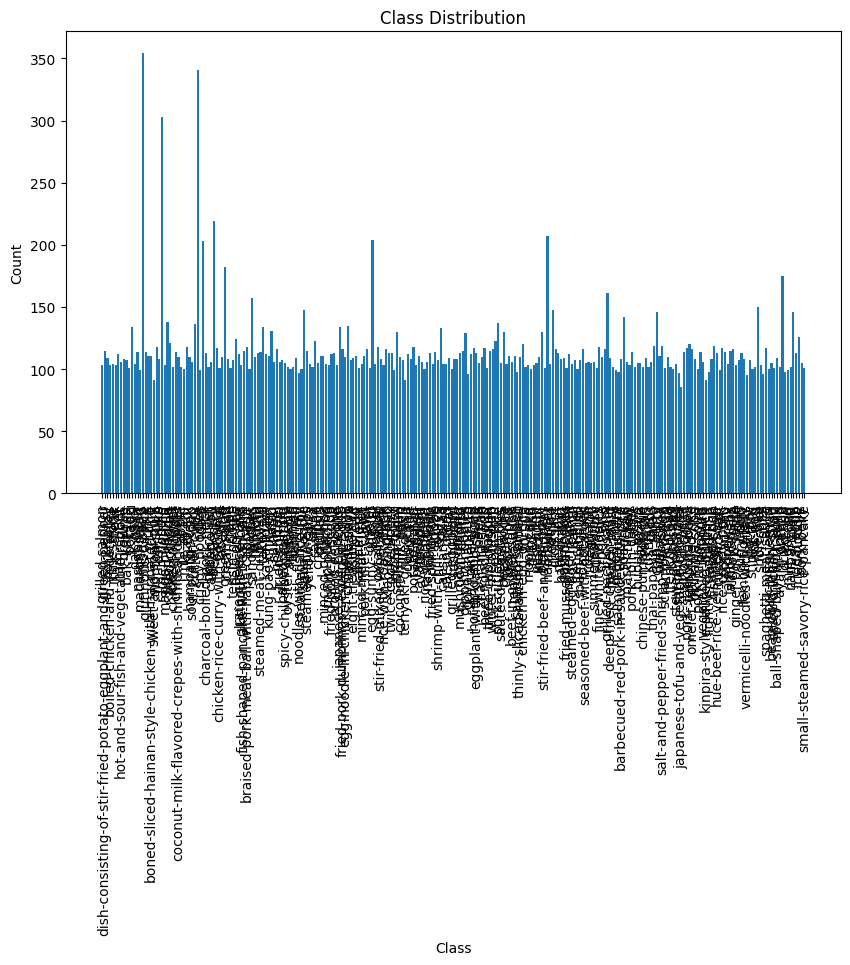

<Figure size 1000x600 with 0 Axes>

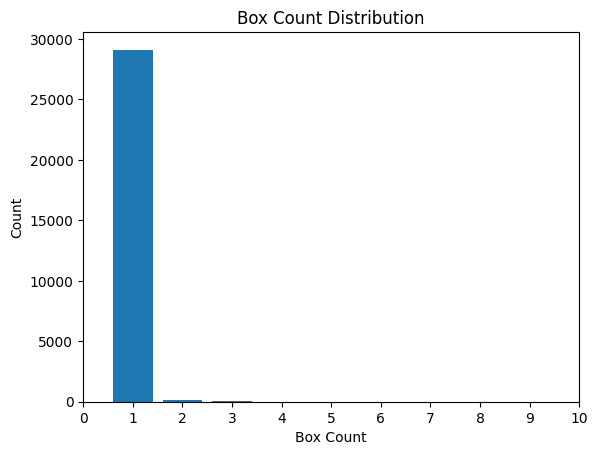

In [8]:
# class distribution count
from collections import defaultdict
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator

class_labels = { i: ds.classes[i] for i in range(len(ds.classes)) }

class_count = defaultdict(int)
box_count = defaultdict(int)
label_dir = unified_dir / 'labels'
label_files = list(label_dir.glob('*.txt'))
print(f"Label files found: {len(label_files)}")
for file in label_files:
    count = 0
    with open(file, 'r') as f:
      for line in f:
        arr = line.split()
        if not arr:
          continue

        i = int(arr[0])
        class_count[class_labels[i]] += 1
        count += 1


    box_count[count] += 1


print(class_count)

# class distribution count
# image size
# aspect ratio
# boxes per image
# noise / blur

# plot
plt.figure(figsize=(10, 6))
plt.bar(class_count.keys(), class_count.values())
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.xticks(rotation=90)
plt.show()

# plot
plt.figure(figsize=(10, 6))
ax = plt.figure().gca()
plt.bar(box_count.keys(), box_count.values())
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlim([0, 10])
plt.xlabel('Box Count')
plt.ylabel('Count')
plt.title('Box Count Distribution')
plt.show()

Images found: 29280


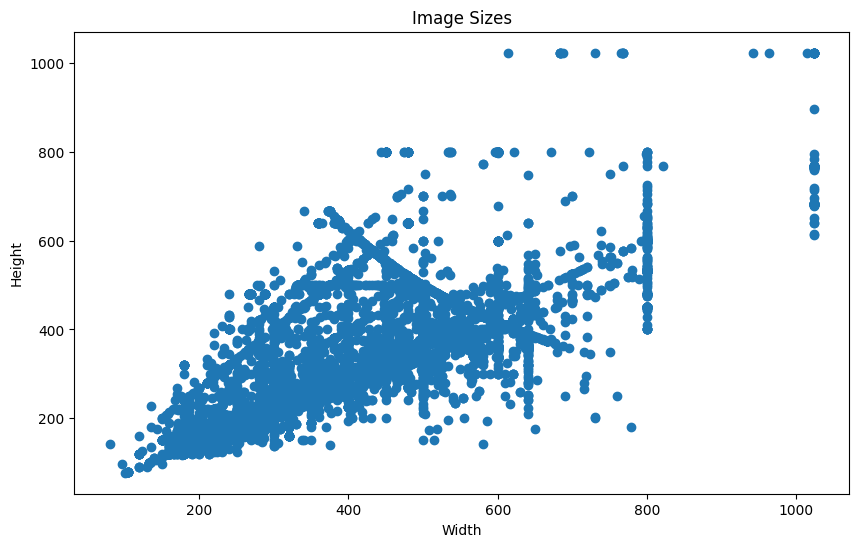

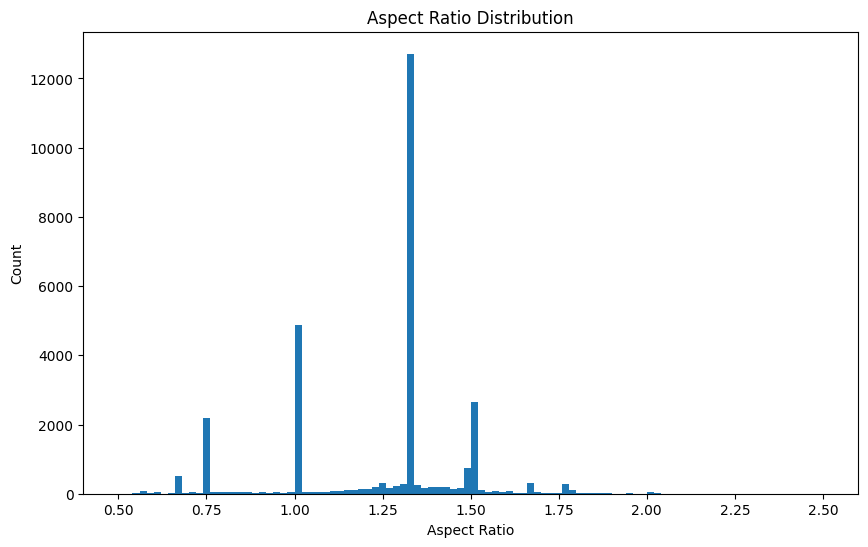

In [9]:
from PIL import Image

# image size
sizes: list[tuple[int, int]] = [] # width x height
img_dir = unified_dir / 'images'
images = list(img_dir.glob('*.jpg'))
print(f"Images found: {len(images)}")
for img in images:
  with Image.open(img) as im:
    sizes.append(im.size)

ratios = [s[0] / s[1] for s in sizes]

# plot
plt.figure(figsize=(10, 6))
plt.scatter([s[0] for s in sizes], [s[1] for s in sizes])
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Image Sizes')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(ratios, bins=100, range=(0.5, 2.5))
plt.xlabel('Aspect Ratio')
plt.ylabel('Count')
plt.title('Aspect Ratio Distribution')
plt.show()

IMAGES FOLDER: /content/split/test/images
IMAGES FOLDER: /content/split/test/images -> 2928
IMAGES FOLDER: /content/split/train/images
IMAGES FOLDER: /content/split/train/images -> 23424
IMAGES FOLDER: /content/split/valid/images
IMAGES FOLDER: /content/split/valid/images -> 2928


In [ ]:
import hashlib
from pathlib import Path

def remove_duplicate_images(images_dir: str, labels_dir: str):
    images_path = Path(images_dir)
    labels_path = Path(labels_dir)

    seen_hashes = {}
    duplicates = []

    for img_file in sorted(images_path.iterdir()):
        if img_file.suffix.lower() not in ('.jpg', '.jpeg', '.png', '.bmp'):
            continue
        h = hashlib.md5(img_file.read_bytes()).hexdigest()
        if h in seen_hashes:
            duplicates.append(img_file)
        else:
            seen_hashes[h] = img_file

    print(f"{len(duplicates)} duplicate images")

    for dup in duplicates:
        dup.unlink()
        label_file = labels_path / (dup.stem + '.txt')
        if label_file.exists():
            label_file.unlink()

    print(f"{len(seen_hashes)} left")

remove_duplicate_images('/content/all/images', '/content/all/labels')

In [ ]:
import cv2
import numpy as np
from pathlib import Path

IMG_DIR = Path('/content/all/images')

enhanced_count = 0
for img_file in sorted(IMG_DIR.glob('*')):
    if img_file.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
        continue

    img = cv2.imread(str(img_file))
    # remove stupid images
    if img is None:
        img_file.unlink()
        label_file = Path('/content/all/labels') / (img_file.stem + '.txt')
        if label_file.exists():
            label_file.unlink()
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mean_brightness = gray.mean()
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    needs_enhance = False

    # flag to change images (not sure if this will work; will revisit if needed)
    if mean_brightness < 50:
        needs_enhance = True

    if laplacian_var < 30 and mean_brightness < 150:
        needs_enhance = True

    if needs_enhance:
        # Apply CLAHE
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        l = clahe.apply(l)
        enhanced = cv2.merge([l, a, b])
        enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)
        cv2.imwrite(str(img_file), enhanced)
        enhanced_count += 1

print(f"changed {enhanced_count} images")

In [ ]:
from pathlib import Path
from PIL import Image, ImageOps

IMG_DIR = Path('/content/all/images')

for img_file in sorted(IMG_DIR.glob('*')):
    if img_file.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
        continue
    pil_img = Image.open(img_file)
    pil_img = ImageOps.exif_transpose(pil_img)
    pil_img.save(img_file)

In [ ]:
import random
import cv2
import numpy as np
from pathlib import Path
from collections import defaultdict


IMG_DIR = Path('/content/all/images')
LBL_DIR = Path('/content/all/labels')

class_to_images = defaultdict(set)  
image_classes = defaultdict(set)  

for lbl_file in LBL_DIR.glob('*.txt'):
    stem = lbl_file.stem
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            class_to_images[cls_id].add(stem)
            image_classes[stem].add(cls_id)

total_images = len(list(IMG_DIR.glob('*.jpg')))
class_counts = {c: len(imgs) for c, imgs in class_to_images.items()}
for c in sorted(class_counts):
    print(f"Class {c}: {class_counts[c]} images")


ABLATION_RATIO = 0.10

ablation_remove = set()
for cls_id, stems in class_to_images.items():
    n_remove = max(1, int(len(stems) * ABLATION_RATIO))
    to_remove = random.sample(sorted(stems), n_remove)
    ablation_remove.update(to_remove)

for stem in ablation_remove:
    img = IMG_DIR / f"{stem}.jpg"
    lbl = LBL_DIR / f"{stem}.txt"
    if img.exists(): img.unlink()
    if lbl.exists(): lbl.unlink()

for cls_id in class_to_images:
    class_to_images[cls_id] -= ablation_remove
class_counts = {c: len(imgs) for c, imgs in class_to_images.items()}


# Threshold = median count (mean idk)
counts = sorted(class_counts.values())
UNDERSAMPLE_CAP = int(np.median(counts))
print(f"median: {UNDERSAMPLE_CAP} images")

undersample_remove = set()
for cls_id, stems in class_to_images.items():
    if len(stems) > UNDERSAMPLE_CAP:
        excess = sorted(stems)
        random.shuffle(excess)
        removed = 0
        for stem in excess:
            if removed >= len(stems) - UNDERSAMPLE_CAP:
                break
            if image_classes[stem] == {cls_id}:
                undersample_remove.add(stem)
                removed += 1
        print(f"  Class {cls_id}: removed {removed} (target was {len(stems) - UNDERSAMPLE_CAP})")

for stem in undersample_remove:
    img = IMG_DIR / f"{stem}.jpg"
    lbl = LBL_DIR / f"{stem}.txt"
    if img.exists(): img.unlink()
    if lbl.exists(): lbl.unlink()

# update counts
for cls_id in class_to_images:
    class_to_images[cls_id] -= undersample_remove
class_counts = {c: len(imgs) for c, imgs in class_to_images.items()}


#Oversampling - augmentions
OVERSAMPLE_TARGET = UNDERSAMPLE_CAP

aug_count = 0
for cls_id, stems in class_to_images.items():
    if len(stems) >= OVERSAMPLE_TARGET:
        continue

    need = OVERSAMPLE_TARGET - len(stems)
    source_stems = sorted(stems)
    print(f"  Class {cls_id}: augmenting {need} images from {len(stems)} originals")

    for i in range(need):
        src_stem = source_stems[i % len(source_stems)]
        src_img_path = IMG_DIR / f"{src_stem}.jpg"
        src_lbl_path = LBL_DIR / f"{src_stem}.txt"

        if not src_img_path.exists():
            continue

        img = cv2.imread(str(src_img_path))

        # random augmentation
        aug_type = random.choice(['brightness', 'rotate', 'shear'])

        if aug_type == 'brightness':
            beta = random.uniform(-30, 30)
            img = cv2.convertScaleAbs(img, alpha=1.0, beta=beta)
        elif aug_type == 'rotate':
            angle = random.uniform(-15, 15)
            h, w = img.shape[:2]
            M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
            img = cv2.warpAffine(img, M, (w, h), borderValue=(114, 114, 114))
        elif aug_type == 'shear':
            shear_x = random.uniform(-0.1, 0.1)
            h, w = img.shape[:2]
            M = np.float32([[1, shear_x, 0], [0, 1, 0]])
            img = cv2.warpAffine(img, M, (w, h), borderValue=(114, 114, 114))

        # new name save
        new_stem = f"{src_stem}_aug{i}"
        cv2.imwrite(str(IMG_DIR / f"{new_stem}.jpg"), img)

        if src_lbl_path.exists():
            import shutil
            shutil.copy(src_lbl_path, LBL_DIR / f"{new_stem}.txt")

        aug_count += 1

print(f"augmented {aug_count} new images")

# final totals
final_images = len(list(IMG_DIR.glob('*.jpg')))
print(f"Dataset size: {total_images} → {final_images} images")

In [ ]:
import supervision as sv
from pathlib import Path

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=str(new_img_dir),
    annotations_directory_path=str(new_label_dir),
    data_yaml_path=str(dir / 'data.yaml')
)

seed = 1
train_ds, rest_ds = ds.split(split_ratio=0.8, random_state=seed, shuffle=True)
test_ds, val_ds = rest_ds.split(split_ratio=0.5, random_state=seed, shuffle=True)

# save splits in yolo format
train_ds.as_yolo(
    images_directory_path=str(split_path / 'train' / 'images'),
    annotations_directory_path=str(split_path / 'train' / 'labels'),
    data_yaml_path=str(split_path / 'train' / 'data.yaml')
)
test_ds.as_yolo(
    images_directory_path=str(split_path / 'test' / 'images'),
    annotations_directory_path=str(split_path / 'test' / 'labels'),
    data_yaml_path=str(split_path / 'test' / 'data.yaml')
)
val_ds.as_yolo(
    images_directory_path=str(split_path / 'valid' / 'images'),
    annotations_directory_path=str(split_path / 'valid' / 'labels'),
    data_yaml_path=str(split_path / 'valid' / 'data.yaml')
)

def write_manifest(ds: sv.DetectionDataset, split: str, output_path: Path):
    with open(output_path, "w") as f:
        for img_path, _, _ in ds:
            f.write(f"{str(Path(img_path).name)}\n")
    print(f"Wrote to {output_path}")

write_manifest(train_ds, "train", Path(split_path) / "train.txt")
write_manifest(test_ds, "test", Path(split_path) / "test.txt")
write_manifest(val_ds, "valid", Path(split_path) / "valid.txt")

# count images per split
import glob, os
for root, dirs, files in os.walk("/content/split", topdown=True):
    if os.path.basename(root) == "images":
        imgs = glob.glob(os.path.join(root, "*.jpg"))
        print(f"{root} -> {len(imgs)} images")

In [ ]:

%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.6 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
from collections import Counter

def count_images_per_class(labels_dir, class_names):
    labels_dir = Path(labels_dir)
    image_count_per_class = Counter()

    for lbl_file in labels_dir.glob('*.txt'):
        with lbl_file.open() as f:
            classes_in_image = set(int(line.split()[0]) for line in f if line.strip())
        for cls_id in classes_in_image:
            image_count_per_class[cls_id] += 1

    print(f"Class distribution in {labels_dir.parent.name}:")
    print("-" * 60)
    for cls_id in range(len(class_names)):
        count = image_count_per_class.get(cls_id, 0)
        print(f"{cls_id:2d} {class_names[cls_id]:30s}: {count:4d} images")
    print("-" * 60)
    return image_count_per_class

train_labels = split_path / 'train' / 'labels'
valid_labels = split_path / 'valid' / 'labels'
test_labels = split_path / 'test' / 'labels'

# Load class names (already available in ds.classes)
class_names = ds.classes

# Count distribution
train_counts = count_images_per_class(train_labels, class_names)
valid_counts = count_images_per_class(valid_labels, class_names)
test_counts = count_images_per_class(test_labels, class_names)


📊 Class distribution in train:
------------------------------------------------------------
 0 adobo                         :   79 images
 1 almond-jelly                  :   84 images
 2 apple                         :   34 images
 3 apple-pie                     :   80 images
 4 ayam-bakar                    :   95 images
 5 ayam-goreng                   :   82 images
 6 babi-guling                   :   77 images
 7 bagel                         :   86 images
 8 bak-kut-teh                   :   84 images
 9 baked-salmon                  :   85 images
10 ball-shaped-bun-with-pork     :   88 images
11 barbecued-red-pork-in-sauce-with-rice:   90 images
12 bean-curd-family-style        :   86 images
13 beef-bowl                     :   96 images
14 beef-curry                    :  175 images
15 beef-in-oyster-sauce          :   93 images
16 beef-noodle                   :  109 images
17 beef-noodle-soup              :   96 images
18 bibimbap                      :   80 images
19 boil

In [ ]:
import yaml

# Use existing split_path from earlier cells
data_yaml_content = {
    'path': str(split_path.resolve()),  # dataset root
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': len(ds.classes),
    'names': ds.classes
}

# Write unified data.yaml
unified_yaml_path = split_path / 'data.yaml'
with open(unified_yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, sort_keys=False)

print(f"Created unified data.yaml at: {unified_yaml_path}")
print(f"Dataset root: {split_path.resolve()}")
print(f"Number of classes: {len(ds.classes)}")

✅ Created unified data.yaml at: /content/split/data.yaml
   Dataset root: /content/split
   Number of classes: 258


In [ ]:
from ultralytics import YOLO


model = YOLO("yolo26s.pt")

training_config = {
    'data': str(unified_yaml_path),

    'epochs': 50,  
    'patience': 20, # early stopping if plateau
    'batch': -1,    # auto-batch: trying this out not sure if it works
    'imgsz': 640,   # standard size
    'save': True,
    'save_period': 10,  # checkpoint every 10 epochs
    
    # ── Optimizer ──
    'optimizer': 'AdamW',
    'lr0': 0.001,   # initial learning rate
    'lrf': 0.01,    # final LR = lr0 * lrf
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,
    'warmup_momentum': 0.8,
    'cos_lr': True,             # cosine annealing
    
    # ── Loss Weights ──
    'box': 7.5,
    'cls': 0.5,
    'dfl': 1.5,
}

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
try:
    results = model.train(**training_config)
    print("Training completed successfully!")
    print("Model saved to: runs/detect/food_yolov8n/weights/best.pt")
except Exception as e:
    print(f"Training encountered an error: {e}")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/split/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=45, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=896, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.008, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=30, pers

In [ ]:
# # if collab dies (not sure if this works)
# from ultralytics import YOLO

# model = YOLO('/content/runs/detect/train/weights/last.pt')
# results = model.train(resume=True)

In [ ]:
from google.colab import drive
import shutil

drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/yolo_weights'
os.makedirs(save_dir, exist_ok=True)

for weight in ['best.pt', 'last.pt']:
    src = f'/content/runs/detect/train/weights/{weight}'
    if os.path.exists(src):
        shutil.copy(src, save_dir)
        print(f"Saved {weight} to {save_dir}")
    else:
        print(f"{weight} not found at {src}")

In [ ]:
print("Running validation")

best_model = YOLO('/content/runs/detect/train/weights/best.pt')
val_results = best_model.val(data=str(unified_yaml_path))

print("Validation Results:")

print(f"mAP@0.5: {val_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {val_results.box.map:.4f}")
print(f"Precision: {val_results.box.mp:.4f}")
print(f"Recall: {val_results.box.mr:.4f}")


Running validation
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 11,225,430 parameters, 0 gradients, 29.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 911.3±500.6 MB/s, size: 40.3 KB)
val: Scanning /content/split/valid/labels.cache... 2928 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2928/2928 877.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 183/183 10.0it/s 18.2s
                   all       2928       2961       0.49      0.486      0.516      0.397
                 adobo         20         20      0.758       0.47      0.688      0.609
          almond-jelly          9          9      0.728        0.6      0.774      0.593
                 apple          4         14       0.39     0.0714      0.102     0.0712
             apple-pie         10         10      0.692        0.7      0.735      0.649
           